(p2-lab-classification)=
# P2 실습: 분류

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 실습 노트북이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**코드 실행**

[(구글 코랩) P1 실습: 분류](https://colab.research.google.com/github/codingalzi/code-workout-ml/blob/master/p1_lab_classification.ipynb)에서 코드를 실행할 수 있다.

**환경설정**

In [1]:
import sys
import sklearn
from packaging.version import Version

# 파이썬 버전과 scikit-learn 버전 확인
assert sys.version_info >= (3, 10)
assert Version(sklearn.__version__) >= Version("1.6.1")

# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## MNIST 데이터와 분류 문제

### MNIST 데이터셋

MNIST는 0부터 9까지의 손글씨 숫자 이미지 70,000개로 구성된 데이터셋이다.

각 이미지는 `(28, 28)` 크기이며, 모델에는 784개의 픽셀값으로 펼친 입력 데이터로 제공된다.  
타깃은 각 이미지가 나타내는 0부터 9까지의 숫자다.

In [51]:
from sklearn.datasets import fetch_openml

# 처음 실행할 때 인터넷 연결이 필요하다.
mnist = fetch_openml("mnist_784", as_frame=False)

X = mnist.data
y = mnist.target

print("입력 데이터:", X.shape)
print("타깃 데이터:", y.shape)
print("타깃:", np.unique(y))

입력 데이터: (70000, 784)
타깃 데이터: (70000,)
타깃: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


### 손글씨 이미지 확인

첫 번째 샘플을 `(28, 28)` 모양으로 바꾸어 이미지로 확인한다.

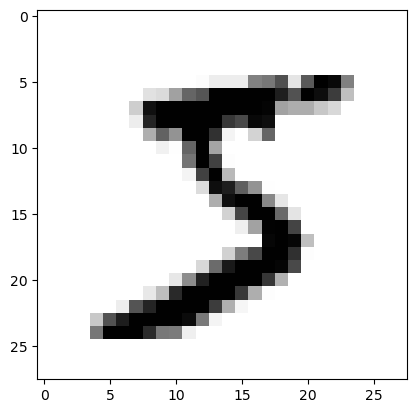

실제 라벨: 5


In [47]:
example_5 = X[0]

plt.imshow(example_5.reshape(28, 28), cmap="binary")
plt.show()

print("실제 라벨:", y[0])

### 훈련셋과 테스트셋

MNIST는 앞의 60,000개 샘플을 훈련셋, 뒤의 10,000개 샘플을 테스트셋으로 사용한다.

테스트셋은 최종 평가 전까지 모델 선택에 사용하지 않는다.

In [4]:
X_train_full, X_test = X[:60000], X[60000:]
y_train_full, y_test = y[:60000], y[60000:]

print("훈련셋:", X_train_full.shape, y_train_full.shape)
print("테스트셋:", X_test.shape, y_test.shape)

훈련셋: (60000, 784) (60000,)
테스트셋: (10000, 784) (10000,)


## 이진 분류와 로지스틱 회귀

### 숫자 5 판별 문제

먼저 **숫자 5인지 아닌지**를 구분하는 이진 분류 문제로 바꾼다.

- 숫자 5 → 양성(`True`)
- 그 밖의 숫자 → 음성(`False`)

In [53]:
y_train_full_5 = (y_train_full == "5")
y_test_5 = (y_test == "5")

훈련셋에서 숫자 5의 비율은 10% 정도이다.

In [54]:
print(y_train_full_5.mean())

0.09035


라벨(타깃)은 `False` 또는 `True`로 구성된다. 

In [55]:
y_test_5

array([False, False, False, ..., False,  True, False], shape=(10000,))

### 학습용과 검증용 데이터

테스트셋을 사용하기 전에 훈련셋 일부를 검증용으로 분리한다.  
숫자 5의 비율이 유지되도록 층화하여 나눈다.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_5, y_val_5 = train_test_split(
    X_train_full,
    y_train_full_5,
    test_size=10000,
    stratify=y_train_full_5,
    random_state=42
)

print("학습용:", X_train.shape)
print("검증용:", X_val.shape)

학습용: (50000, 784)
검증용: (10000, 784)


### 로지스틱 회귀 모델

로지스틱 회귀는 입력 특성으로부터 **양성 클래스에 속할 확률**을 계산하고, 그 확률을 기준으로 클래스를 예측하는 분류 모델이다.

픽셀값을 0과 1 사이의 값으로 변환한 뒤 `LogisticRegression`을 훈련한다.
또한 전처리 과정과 모델을 하나의 파이프라인으로 묶어서 처리함에 주의한다.

In [46]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

binary_clf = make_pipeline(
    MinMaxScaler(),           # 데이터를 0~1 범위로 스케일링
    LogisticRegression(
        max_iter=300,
        tol=1e-3,
        random_state=42
    )
)

binary_clf.fit(X_train, y_train_5)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('minmaxscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l

훈련된 로지스틱 회귀 모델이 앞서 살펴본 5를 가리키는 이미지를 숫자 5라고 정확히 예측한다.
즉, 양성 이미지를 양성으로 정확히 판정한다.

In [48]:

binary_clf.predict([example_5])

array([ True])

### 혼동 행렬

혼동 행렬은 실제값과 예측값을 네 경우로 구분한다.

| | 예측 음성 | 예측 양성 |
|---|---:|---:|
| **실제 음성** | TN (참 거짓) | FP (거짓 양성) |
| **실제 양성** | FN (거짓 음성) | TP (참 양성) |

숫자 자체보다 **어떤 종류의 오류가 발생했는지**를 읽는 것이 중요하다.

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred = binary_clf.predict(X_val)

cm = confusion_matrix(y_val_5, y_val_pred)
cm

array([[9032,   65],
       [ 205,  698]])

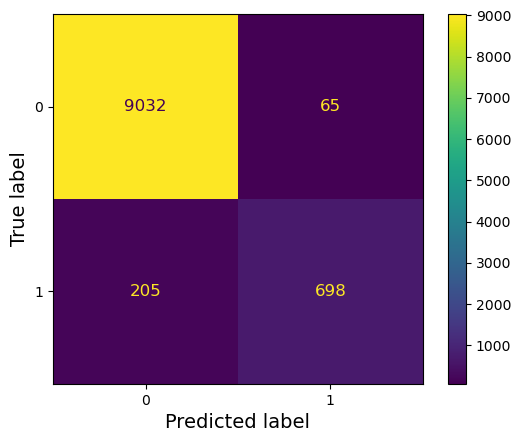

In [33]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

### 정확도의 한계

숫자 5는 전체의 약 10%다. 따라서 모든 이미지를 “5가 아니다”라고 예측해도 높은 정확도가 나올 수 있다.

클래스 비율이 불균형한 문제에서는 정확도만으로 모델을 평가하기 어렵다.

In [34]:
from sklearn.metrics import accuracy_score

never_5_pred = np.zeros_like(y_val_5, dtype=bool)

print(
    "항상 '5가 아니다'라고 예측할 때의 정확도:",
    accuracy_score(y_val_5, never_5_pred)
)

print(
    "로지스틱 회귀 정확도:",
    accuracy_score(y_val_5, y_val_pred)
)

항상 '5가 아니다'라고 예측할 때의 정확도: 0.9097
로지스틱 회귀 정확도: 0.973


### 정밀도와 재현율

- **정밀도(precision)**: 양성이라고 예측한 것 중 실제 양성의 비율
- **재현율(recall)**: 실제 양성 중 모델이 찾아낸 비율

어떤 지표가 더 중요한지는 문제의 목적에 따라 달라진다.

In [35]:
from sklearn.metrics import precision_score, recall_score

print("정밀도:", precision_score(y_val_5, y_val_pred))
print("재현율:", recall_score(y_val_5, y_val_pred))

정밀도: 0.9148099606815203
재현율: 0.7729789590254706


### 예측 확률과 결정 임곗값

`predict_proba()`는 각 클래스에 속할 확률을 반환한다.

양성 클래스의 확률이 일정 기준 이상이면 양성으로 분류할 수 있다.  
이 **결정 임곗값**을 바꾸면 정밀도와 재현율도 달라진다.

로지스틱 회귀 모델의 기본 결정 임곗값은 0.5이다.

In [36]:
y_val_proba = binary_clf.predict_proba(X_val)
y_val_scores = y_val_proba[:, 1]

print(y_val_proba[:5])

[[9.94899963e-01 5.10003733e-03]
 [9.85769770e-01 1.42302305e-02]
 [9.97863815e-01 2.13618530e-03]
 [9.99436832e-01 5.63167874e-04]
 [9.99996283e-01 3.71654094e-06]]


### 정밀도와 재현율의 트레이드오프

정밀도와 재현율은 상호 트레이드오프(trade-off) 관계를 갖는다.

- 임곗값을 높이면 양성으로 판단하는 샘플이 줄어드는 경향이 있다.
    정밀도는 높아지고 재현율은 낮아질 수 있다.
- 임곗값을 낮추면 양성으로 판단하는 샘플이 많아진다. 정밀도는 낮아지고 재현율은 올라갈 수 있다.

아래 코드는 결정 임곗값을 0부터 1까지 변화시킬 때 정밀도와 재현율의 변화를 그래프로 그린다.

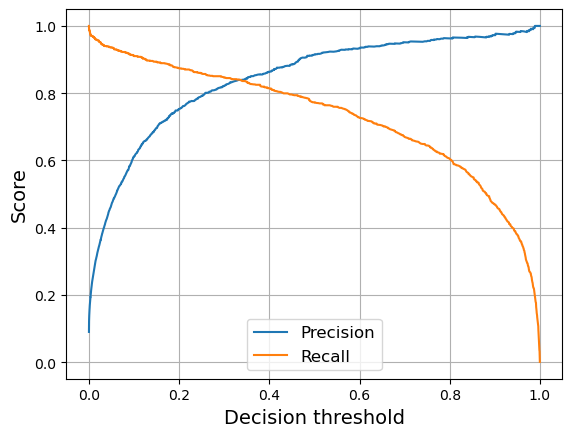

In [37]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_val_5,
    y_val_scores
)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

아래 코드는 앞서 구한 결정 임곗값에 따른 정밀도와 재현율의 트레이드오프 관계를 직접 보여준다.

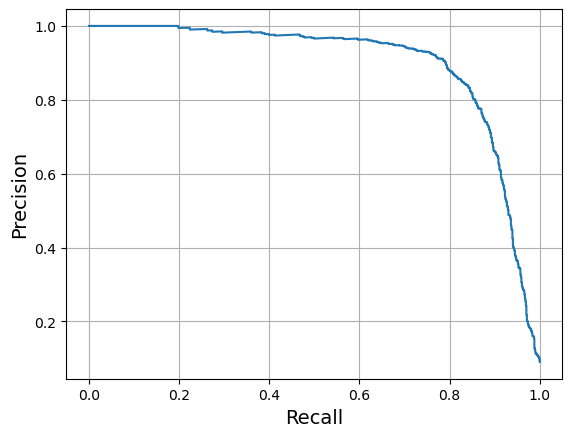

In [38]:
plt.plot(recalls, precisions)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

### ROC 곡선과 AUC

ROC 곡선은 결정 임곗값을 바꾸면서 다음 두 비율의 관계를 나타낸다.

- **TPR(True Positive Rate)**: 실제 양성 중 양성으로 올바르게 예측한 비율. 재현율과 같다.
- **FPR(False Positive Rate)**: 실제 음성 중 양성으로 잘못 예측한 비율

좋은 분류기는 가능한 한 **TPR은 높고 FPR은 낮아야 한다.**

AUC(Area Under the Curve)는 ROC 곡선 아래의 면적이다.

- `AUC = 1`에 가까울수록 양성과 음성을 잘 구분한다.
- `AUC = 0.5` 정도면 무작위 분류와 비슷하다.

ROC-AUC는 여러 임곗값에서의 분류 성능을 하나의 값으로 요약한다.  
다만 양성 클래스가 매우 드문 문제에서는 ROC-AUC와 함께 **정밀도-재현율 관계도 함께 확인하는 것이 좋다.**

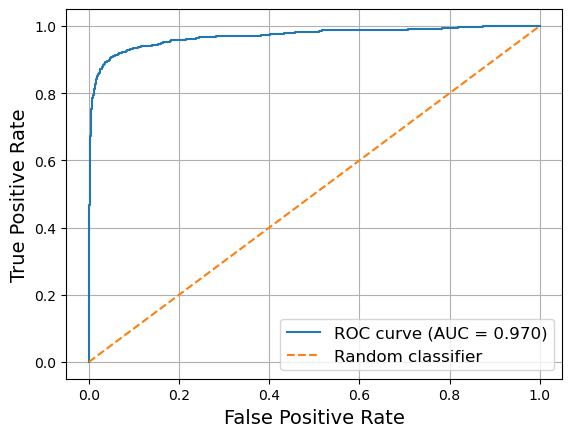

ROC-AUC: 0.9698722675298138


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(
    y_val_5,
    y_val_scores
)

roc_auc = roc_auc_score(
    y_val_5,
    y_val_scores
)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC:", roc_auc)

### 목표에 맞게 임곗값을 선택한다

예를 들어 정밀도를 약 90% 이상으로 만들고 싶다면 그 조건을 만족하는 임곗값을 찾을 수 있다.

중요한 것은 특정 값 자체가 아니라 **문제의 목적에 맞게 정밀도와 재현율의 균형을 정하는 것**이다.

In [40]:
target_precision = 0.90

idx = np.argmax(precisions[:-1] >= target_precision)
threshold_for_90_precision = thresholds[idx]

y_val_pred_90 = (y_val_scores >= threshold_for_90_precision)

print("선택한 임곗값:", threshold_for_90_precision)
print("정밀도:", precision_score(y_val_5, y_val_pred_90))
print("재현율:", recall_score(y_val_5, y_val_pred_90))

선택한 임곗값: 0.4668632662971824
정밀도: 0.9003783102143758
재현율: 0.7906976744186046


### 이진 분류 확인

다음을 설명할 수 있는지 확인한다.

- 정확도가 높아도 좋은 분류기라고 단정할 수 없는 이유
- FP와 FN의 차이
- 정밀도와 재현율의 차이
- `predict()`와 `predict_proba()`의 차이
- 결정 임곗값을 바꾸면 결과가 달라지는 이유
- ROC 곡선과 AUC가 무엇을 나타내는지

## 다중 클래스 로지스틱 회귀

### 0부터 9까지 분류한다

이제 원래 타깃을 사용하여 10개의 숫자를 구분하는 **다중 클래스 분류**를 수행한다.

학습용과 검증용 데이터도 원래 숫자 라벨을 이용해 다시 나눈다.

In [57]:
X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X_train_full,
    y_train_full,
    test_size=10000,
    stratify=y_train_full,
    random_state=42
)

### 다중 클래스 로지스틱 회귀

`LogisticRegression`은 클래스가 여러 개인 경우에도 사용할 수 있다.

각 숫자 클래스에 대한 확률을 계산하고, 가장 높은 확률의 클래스를 최종 예측값으로 선택한다.

In [58]:
multi_clf = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(
        max_iter=300,
        tol=1e-3,
        random_state=42
    )
)

multi_clf.fit(X_train_multi, y_train_multi)

y_val_multi_pred = multi_clf.predict(X_val_multi)

print(
    "검증 정확도:",
    accuracy_score(y_val_multi, y_val_multi_pred)
)

검증 정확도: 0.9207


### 클래스별 예측 확률

몇 개의 샘플에 대해 각 숫자 클래스의 예측 확률을 확인한다.

In [59]:
sample_proba = multi_clf.predict_proba(X_val_multi[:5])
sample_pred = multi_clf.predict(X_val_multi[:5])

classes = multi_clf.named_steps["logisticregression"].classes_

prob_table = pd.DataFrame(
    sample_proba,
    columns=classes
)

prob_table["predicted"] = sample_pred
prob_table["actual"] = y_val_multi[:5]

prob_table

,0,1,2,3,4,5,6,7,8,9,predicted,actual
0,0.000079,3.854856e-09,1.685379e-04,0.004140,8.229242e-07,0.000075,2.655795e-09,9.951114e-01,0.000022,0.000402,7,7
1,0.000047,3.581261e-02,2.361188e-01,0.017316,8.148360e-05,0.008134,6.936808e-04,5.805385e-06,0.701277,0.000514,8,8
2,0.000034,2.145424e-09,1.318214e-07,0.000074,9.486976e-01,0.001029,1.506091e-04,3.481771e-04,0.000144,0.049522,4,4
3,0.000010,7.497343e-01,1.133975e-03,0.000292,2.057449e-05,0.010952,3.502432e-02,3.363602e-07,0.202106,0.000727,1,8
4,0.002685,6.967433e-04,9.591319e-01,0.009111,1.731905e-08,0.010305,1.089035e-03,1.314317e-10,0.016980,0.000001,2,2


### 다중 클래스 혼동 행렬

전체 정확도만으로는 어떤 숫자를 자주 혼동하는지 알 수 없다.

행은 실제 숫자, 열은 예측 숫자를 나타내는 **정규화된 혼동 행렬을 표로 확인한다.**

In [61]:
from sklearn.metrics import confusion_matrix

cm_multi = confusion_matrix(
    y_val_multi,
    y_val_multi_pred,
    normalize="true"
)

cm_multi_table = pd.DataFrame(
    cm_multi,
    index=[f"실제 {i}" for i in range(10)],
    columns=[f"예측 {i}" for i in range(10)]
)

cm_multi_table.round(3)

,예측 0,예측 1,예측 2,예측 3,예측 4,예측 5,예측 6,예측 7,예측 8,예측 9
실제 0,0.971,0.000,0.002,0.000,0.002,0.009,0.008,0.001,0.005,0.002
실제 1,0.000,0.970,0.007,0.004,0.001,0.003,0.000,0.001,0.012,0.003
실제 2,0.004,0.015,0.886,0.024,0.008,0.006,0.016,0.008,0.029,0.003
실제 3,0.004,0.003,0.023,0.890,0.000,0.034,0.003,0.009,0.024,0.009
실제 4,0.002,0.004,0.006,0.001,0.928,0.000,0.010,0.004,0.006,0.038
실제 5,0.011,0.004,0.012,0.030,0.014,0.880,0.008,0.003,0.023,0.013
실제 6,0.008,0.002,0.005,0.000,0.010,0.018,0.951,0.000,0.004,0.001
실제 7,0.002,0.006,0.014,0.004,0.010,0.002,0.001,0.922,0.003,0.036
실제 8,0.011,0.019,0.010,0.029,0.003,0.026,0.008,0.001,0.882,0.010
실제 9,0.004,0.008,0.000,0.009,0.017,0.004,0.001,0.030,0.010,0.916


### 오분류만 따로 본다

혼동 행렬의 대각선은 올바른 예측이다.  
대각선을 0으로 바꾸면 **어떤 숫자를 다른 숫자로 잘못 분류하는지** 표에서 더 쉽게 확인할 수 있다.

In [ ]:
from sklearn.metrics import confusion_matrix

cm_errors = cm_multi.copy()
np.fill_diagonal(cm_errors, 0)

cm_errors_table = pd.DataFrame(
    cm_errors,
    index=[f"실제 {i}" for i in range(10)],
    columns=[f"예측 {i}" for i in range(10)]
)

cm_errors_table.round(3)

,예측 0,예측 1,예측 2,예측 3,예측 4,예측 5,예측 6,예측 7,예측 8,예측 9
실제 0,0.000,0.000,0.002,0.000,0.002,0.009,0.008,0.001,0.005,0.002
실제 1,0.000,0.000,0.007,0.004,0.001,0.003,0.000,0.001,0.012,0.003
실제 2,0.004,0.015,0.000,0.024,0.008,0.006,0.016,0.008,0.029,0.003
실제 3,0.004,0.003,0.023,0.000,0.000,0.034,0.003,0.009,0.024,0.009
실제 4,0.002,0.004,0.006,0.001,0.000,0.000,0.010,0.004,0.006,0.038
실제 5,0.011,0.004,0.012,0.030,0.014,0.000,0.008,0.003,0.023,0.013
실제 6,0.008,0.002,0.005,0.000,0.010,0.018,0.000,0.000,0.004,0.001
실제 7,0.002,0.006,0.014,0.004,0.010,0.002,0.001,0.000,0.003,0.036
실제 8,0.011,0.019,0.010,0.029,0.003,0.026,0.008,0.001,0.000,0.010
실제 9,0.004,0.008,0.000,0.009,0.017,0.004,0.001,0.030,0.010,0.000


### 오류 분석

혼동 행렬을 보고 다음을 생각한다.

- 어떤 숫자가 상대적으로 잘 분류되는가?
- 어떤 숫자 쌍에서 오분류가 많이 발생하는가?
- 전체 정확도만 보았을 때 놓칠 수 있는 정보는 무엇인가?

## 최종 테스트셋에서 확인한다

검증 단계에서 모델과 평가 방법을 정한 뒤 마지막으로 테스트셋을 사용한다.

먼저 이진 분류에서는 검증셋에서 정한 임곗값을 그대로 적용한다.

In [65]:
binary_clf.fit(X_train_full, y_train_full_5)

test_scores = binary_clf.predict_proba(X_test)[:, 1]
y_test_pred_90 = (test_scores >= threshold_for_90_precision)

print("테스트 정밀도:", precision_score(y_test_5, y_test_pred_90))
print("테스트 재현율:", recall_score(y_test_5, y_test_pred_90))

테스트 정밀도: 0.8951911220715166
테스트 재현율: 0.8139013452914798


다중 클래스 모델도 전체 훈련셋으로 다시 학습한 뒤 테스트셋에서 최종 정확도와 혼동 행렬을 확인한다.

In [66]:
multi_clf.fit(X_train_full, y_train_full)

y_test_multi_pred = multi_clf.predict(X_test)

print(
    "테스트 정확도:",
    accuracy_score(y_test, y_test_multi_pred)
)

cm_test = confusion_matrix(
    y_test,
    y_test_multi_pred,
    normalize="true"
)

pd.DataFrame(
    cm_test,
    index=[f"실제 {i}" for i in range(10)],
    columns=[f"예측 {i}" for i in range(10)]
).round(3)

테스트 정확도: 0.9214


,예측 0,예측 1,예측 2,예측 3,예측 4,예측 5,예측 6,예측 7,예측 8,예측 9
실제 0,0.980,0.000,0.002,0.002,0.000,0.006,0.007,0.002,0.001,0.000
실제 1,0.000,0.978,0.002,0.002,0.000,0.002,0.004,0.002,0.011,0.000
실제 2,0.007,0.009,0.888,0.017,0.007,0.005,0.015,0.011,0.035,0.008
실제 3,0.002,0.000,0.018,0.908,0.000,0.030,0.004,0.012,0.020,0.007
실제 4,0.001,0.002,0.004,0.001,0.927,0.000,0.012,0.005,0.008,0.040
실제 5,0.011,0.003,0.004,0.040,0.010,0.861,0.020,0.007,0.035,0.008
실제 6,0.013,0.003,0.005,0.001,0.010,0.015,0.947,0.003,0.003,0.000
실제 7,0.002,0.008,0.021,0.007,0.008,0.001,0.000,0.924,0.003,0.026
실제 8,0.007,0.007,0.007,0.026,0.009,0.023,0.011,0.008,0.891,0.010
실제 9,0.011,0.008,0.001,0.011,0.030,0.007,0.001,0.025,0.007,0.900


## 마무리

이번 실습의 핵심은 다음과 같다.

- 이진 분류에서는 정확도뿐 아니라 혼동 행렬, 정밀도, 재현율을 함께 본다.
- 로지스틱 회귀는 클래스뿐 아니라 클래스별 확률도 예측할 수 있다.
- 결정 임곗값을 바꾸면 정밀도와 재현율의 균형이 달라진다.
- ROC 곡선과 AUC는 여러 임곗값에서의 분류 성능을 요약한다.
- 같은 로지스틱 회귀 모델로 다중 클래스 분류도 수행할 수 있다.
- 다중 클래스 문제에서는 혼동 행렬을 이용한 오류 분석이 중요하다.